## 2. Plotting the dynamic sea level

This note plots dynamic sea level aggregated data. [Additionally we load a table and group the result by average melting in 2100, 2200 and 2300 and and melt parameterization.]

In [19]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import scipy.stats as stats 
sns.set_context("paper")
sns.set_style("whitegrid")

computed_dir = '/home/sxc581/mnt/ncihome/ismip6_hackathon/ComputedScalars'
computed_dir_helene = '/home/sxc581/mnt/ncihome/ismip6_hackathon/ComputedScalarsHelene'
figures_dir = '/home/sxc581/mnt/ncihome/ismip6_hackathon/figures'


In [20]:
# Get: Group, Model, Experiment, Climate forcing, Model setup, fileID, Main submission, Melt parameterisation, Melt parameters
df = pd.read_csv('Metadata_SC.txt', usecols=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16])
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0

# Define constants for conversion
rhow= 1028
oceanarea = 361e6*1000**2 # m2 

# Set time var for all data
time=np.arange(2015,2300) # common start/end time
i_2100= np.argwhere(time == 2099)[0][0]
i_2200= np.argwhere(time == 2199)[0][0]
i_2300= np.argwhere(time == 2299)[0][0]

expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

In [21]:
# function to make all timeseries same start & end date
def subset_all(time,data):
    i2016 = np.argwhere(time == 2016)[0][0]
    i2299 = np.argwhere(time == 2299)[0][0]
    timenew = time[i2016:i2299+1]
    datanew = data[i2016:i2299+1]
    return timenew, datanew

## Get the DSLC, anomaly wrt control
Output the data into the dictionary dic_dslc and dic_dslctime

In [22]:
# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}

# Loop to populate dictionary with dslc data from all models and experiments
dic_dslc = {}
dic_dslc_wais = {}
dic_dslc_eais = {}
dic_dslc_ap = {}

# use a list of dictionaries for the sectors rather than a dict for each
# here an empty list of length 18 which gets filled subsequently with the 
dic_dslc_secs = [{} for _ in range(18)]

dic_dslctime = {}

for iexp, expname in enumerate(expnames):
    # create new dictionary for each experiment; key is model
    dic_all = {}
    dic_alltime = {}
    
    dic_wais = {}
    dic_eais = {}
    dic_ap = {}

    # list of empty dictionaries of length 18
    dic_secs = [{} for _ in range(18)]

    file_exp = os.listdir(f"{computed_dir}/{expname}/dslc_anom")
    file_exp = [file for file in file_exp if len(file) >= 3]

    # remove some files if less than 3 datasets in experiment
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]
            print('Deleted file:'+str(ifile))

    # dictionary referenced by model run name
    for ifile in range(len(file_exp)):
        filename = f"{computed_dir}/{expname}/dslc_anom/{file_exp[ifile]}"
        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]

        # convert Gt to mm water equiv gmsl
        d = xr.open_dataset(filename,decode_times=False )
        data_all = -1 * d.dslc_anom.values*1e12/rhow/oceanarea # all Antarctica
        time = d.time.values
        
        data_wais = -1 * d.dslc_anom_region_1.values*1e12/rhow/oceanarea # just WAIS
        data_eais = -1 * d.dslc_anom_region_2.values*1e12/rhow/oceanarea # just EAIS
        data_ap = -1 * d.dslc_anom_region_3.values*1e12/rhow/oceanarea # just Ant Peninsula

        # another empty list to fill the time series
        data_secs = [None] * 18

        # fill the empty list with all the sectors
        for i_sec in range(18):
            data_secs[i_sec] = -1 * d['dslc_anom_sector_' + str(i_sec+1)].values * 1e12 / rhow / oceanarea
        
        # check: are dslc and time variables same length?
        if len(data_all) != len(time):
            print('Error: dslc \n')
            print(filename)
            break

        # subset so all datasets are same length
        time,data_all = subset_all(time,data_all)
        time,data_wais = subset_all(time,data_wais)
        time,data_eais = subset_all(time,data_eais)
        time,data_ap = subset_all(time,data_ap)

        for i_sec in range(18):
            time, data_secs[i_sec] = subset_all(time, data_secs[i_sec])
        
        dic_all[modelrun] = data_all
        dic_alltime[modelrun] = time
        dic_wais[modelrun] = data_wais
        dic_eais[modelrun] = data_eais
        dic_ap[modelrun] = data_ap

        # add the data to the relevant dictionaries
        for i_sec in range(18):
            dic_secs[i_sec][modelrun] = data_secs[i_sec]
                
        if len(data_all) > 250:
            valuesend_dict[expname].append(data_all[time.size-1])
            df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2100'] = data_all[i_2100-5:i_2100+5].mean()
            df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2200'] = data_all[i_2200-5:i_2200+5].mean()
            df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2300'] = data_all[i_2300-5:i_2300].mean()
        else:
            print("Error: " + df['Experiment'] + " is too short. Excluding from file list")

    # save all data from each experiment as sub-dictionary
    dic_dslc[expname]=dic_all
    dic_dslctime[expname]=dic_alltime
    
    dic_dslc_wais[expname]=dic_wais
    dic_dslc_eais[expname]=dic_eais
    dic_dslc_ap[expname]=dic_ap

    for i_sec in range(18):
        dic_dslc_secs[i_sec][expname] = dic_secs[i_sec]
   

# Run statistics to see what model choices affect dslc anomalies @ 2300

Initialisation: DSLC TtestResult(statistic=-3.535526075008377, pvalue=0.0007811230060006418, df=61.333834121246376)
Bedrock change: DSLC TtestResult(statistic=3.3508126725981167, pvalue=0.0021720409252033532, df=30.28321843772828)


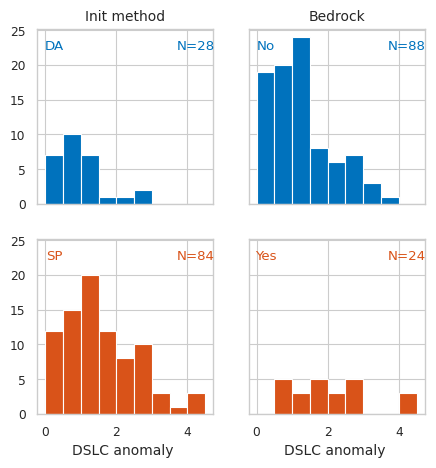

In [23]:
# NB (I think) I've removed a lot of PISM runs because there were so many I worried it could skew the results
# Explore parameters with binary options: Melt in partially floating cells, GIA, initialisation method
# Options I've excluded because found no signficant difference: Grounding line melt, treatment, friction

# Figure settings
f, ax = plt.subplots(2,2, figsize=(5,5), sharey=True, sharex=True)
colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

# Initialisation method stats
y1 = df.loc[(df['Init method']=='DA'),'dslc2300']
y2 = df.loc[(df['Init method']=='SP'),'dslc2300']
print('Initialisation: DSLC', stats.ttest_ind(y1[~np.isnan(y1)], y2[~np.isnan(y2)], equal_var = False)) 

# GIA stats
y1 = df.loc[(df['Bedrock']=='Yes'),'dslc2300']
y2 = df.loc[(df['Bedrock']=='No'),'dslc2300']
print('Bedrock change: DSLC', stats.ttest_ind(y1[~np.isnan(y1)], y2[~np.isnan(y2)], equal_var = False)) 

# Plot histograms
b = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
   
for i, name in enumerate(df['Init method'].unique()):
    ax[i,0].hist(df.loc[(df['Init method']==name),'dslc2300'],bins=b,color=colors[i])
    ax[i,0].text(0.1,0.9,name,color=colors[i], horizontalalignment='center', verticalalignment='center', transform=ax[i,0].transAxes)
    ax[i,0].text(0.9,0.9,'N='+str(sum(~np.isnan(df.loc[(df['Init method']==name),'dslc2300']))),color=colors[i], horizontalalignment='center',verticalalignment='center', transform=ax[i,0].transAxes)
    ax[0,0].set_title('Init method', fontsize=10)

for i, name in enumerate(df['Bedrock'].unique()):
    ax[i,1].hist(df.loc[(df['Bedrock']==name),'dslc2300'],bins=b,color=colors[i])
    ax[i,1].text(0.1,0.9,name,color=colors[i], horizontalalignment='center',verticalalignment='center', transform=ax[i,1].transAxes)
    ax[i,1].text(0.9,0.9,'N='+str(sum(~np.isnan(df.loc[(df['Bedrock']==name),'dslc2300']))),color=colors[i], horizontalalignment='center',verticalalignment='center', transform=ax[i,1].transAxes)
    ax[0,1].set_title('Bedrock', fontsize=10)
    
for i in range(2):
    ax[1,i].set_xlabel('DSLC anomaly (mm we)', fontsize=10)
    
plt.show()

Climate Forcing: KruskalResult(statistic=8.43076124255009, pvalue=0.037899561080674535)
Melt param: KruskalResult(statistic=14.059095218940342, pvalue=0.0008853322059203838)
Ice front: KruskalResult(statistic=28.349915342243094, pvalue=3.0668339822628405e-06)
Stress balance: KruskalResult(statistic=40.64660945683585, pvalue=7.770854327152924e-09)


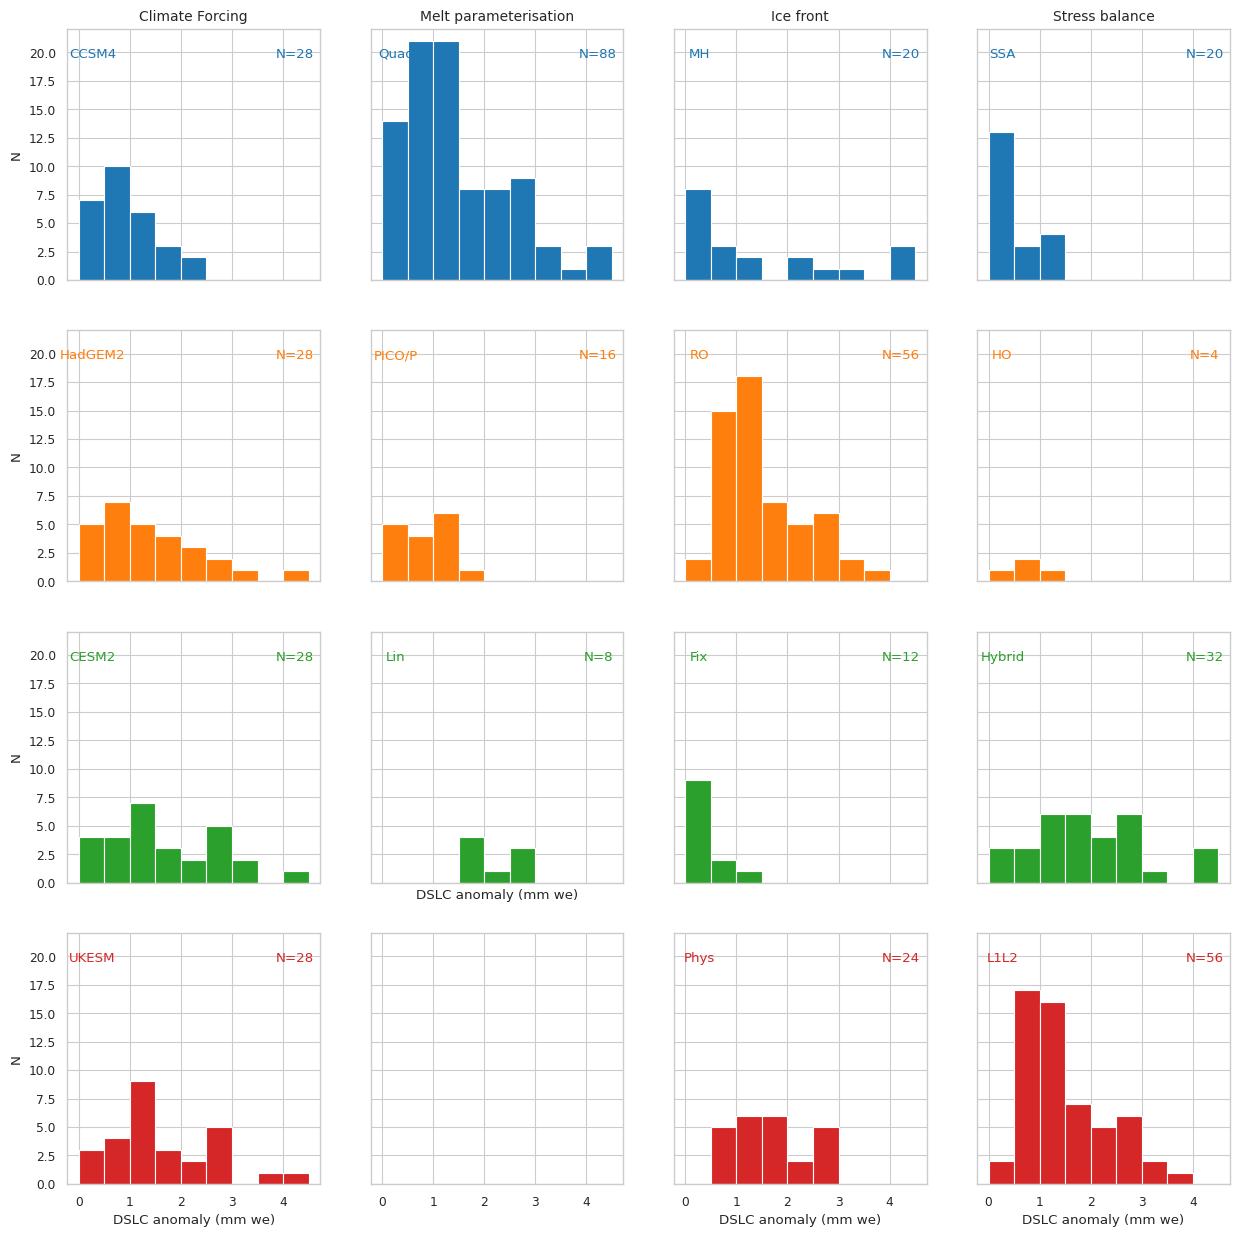

In [34]:
# Explore parameters with multiple options via Kruskal method: Climate forcing, stress balance, resolution, ice front options, melt parameterisation
# Others to consider - friction law

f, ax = plt.subplots(4,4, figsize=(15,15), sharey=True, sharex=True)
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
b = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
#b = [-2.5e12, -2.0e12, -1.5e12, -1.0e12, -0.5e12, 0e12] ## Bins for GA

## Plot 1: Climate model
for i, name in enumerate(df['Climate Forcing'].unique()):
    if name != 'ctrl':
        ax[i-1,0].hist(df.loc[(df['Climate Forcing']==name),'dslc2300'],bins=b,color=colors[i-1])
        ax[i-1,0].text(0.1,0.9,name,color=colors[i-1], horizontalalignment='center',verticalalignment='center', transform=ax[i-1,0].transAxes)
        ax[i-1,0].text(0.9,0.9,'N='+str(sum(~np.isnan(df.loc[(df['Climate Forcing']==name),'dslc2300']))),color=colors[i-1], horizontalalignment='center',verticalalignment='center', transform=ax[i-1,0].transAxes)
        ax[0,0].set_title('Climate Forcing', fontsize=10)
        ax[i-1,0].set_ylabel('N')
ax[i-1,0].set_xlabel('DSLC anomaly (mm we)')
y1 = df.loc[(df['Climate Forcing']=='CCSM4'),'dslc2300']
y2 = df.loc[(df['Climate Forcing']=='HadGEM2'),'dslc2300']
y3 = df.loc[(df['Climate Forcing']=='CESM2'),'dslc2300']
y4 = df.loc[(df['Climate Forcing']=='UKESM'),'dslc2300']
print('Climate Forcing:',stats.kruskal(y1,y2,y3,y4,nan_policy='omit'))

## Plot 2: Melt parameterisation
for i, name in enumerate(df['Melt parameterisation'].unique()):
    ax[i,1].hist(df.loc[(df['Melt parameterisation']==name),'dslc2300'],bins=b,color=colors[i])
    ax[i,1].text(0.1,0.9,name,color=colors[i], horizontalalignment='center', verticalalignment='center', transform=ax[i,1].transAxes)
    ax[i,1].text(0.9,0.9,'N='+str(sum(~np.isnan(df.loc[(df['Melt parameterisation']==name),'dslc2300']))),color=colors[i], horizontalalignment='center',verticalalignment='center', transform=ax[i,1].transAxes)
    ax[0,1].set_title('Melt parameterisation', fontsize=10)
ax[i,1].set_xlabel('DSLC anomaly (mm we)')    
y1 = df.loc[(df['Melt parameterisation']=='Lin'),'dslc2300']
y2 = df.loc[(df['Melt parameterisation']=='Quad'),'dslc2300']
y3 = df.loc[(df['Melt parameterisation']=='PICO/P'),'dslc2300']
print('Melt param:',stats.kruskal(y1,y2,y3,nan_policy='omit'))

## Plot 3: Ice front
for i, name in enumerate(df['Ice front'].unique()):
    ax[i,2].hist(df.loc[(df['Ice front']==name),'dslc2300'],bins=b,color=colors[i])
    ax[i,2].text(0.1,0.9,name,color=colors[i], horizontalalignment='center', verticalalignment='center', transform=ax[i,2].transAxes)
    ax[i,2].text(0.9,0.9,'N='+str(sum(~np.isnan(df.loc[(df['Ice front']==name),'dslc2300']))),color=colors[i], horizontalalignment='center',verticalalignment='center', transform=ax[i,2].transAxes)
    ax[0,2].set_title('Ice front', fontsize=10)
ax[i,2].set_xlabel('DSLC anomaly (mm we)')      
y1 = df.loc[(df['Ice front']=='MH'),'dslc2300']
y2 = df.loc[(df['Ice front']=='RO'),'dslc2300']
y3 = df.loc[(df['Ice front']=='Fix'),'dslc2300']
y4 = df.loc[(df['Ice front']=='Phys'),'dslc2300']
print('Ice front:',stats.kruskal(y1,y2,y3,y4,nan_policy='omit'))

## Plot 4: Stress balance
for i, name in enumerate(df['Stress balance'].unique()):
    ax[i,3].hist(df.loc[(df['Stress balance']==name),'dslc2300'],bins=b,color=colors[i])
    ax[i,3].text(0.1,0.9,name,color=colors[i], horizontalalignment='center', verticalalignment='center', transform=ax[i,3].transAxes)
    ax[i,3].text(0.9,0.9,'N='+str(sum(~np.isnan(df.loc[(df['Stress balance']==name),'dslc2300']))),color=colors[i], horizontalalignment='center',verticalalignment='center', transform=ax[i,3].transAxes)
    ax[0,3].set_title('Stress balance', fontsize=10)
ax[i,3].set_xlabel('DSLC anomaly (mm we)')      
y1 = df.loc[(df['Stress balance']=='HO'),'dslc2300']
y2 = df.loc[(df['Stress balance']=='SSA'),'dslc2300']
y3 = df.loc[(df['Stress balance']=='Hybrid'),'dslc2300']
y4 = df.loc[(df['Stress balance']=='L1L2'),'dslc2300']
print('Stress balance:',stats.kruskal(y1,y2,y3,y4, nan_policy='omit'))

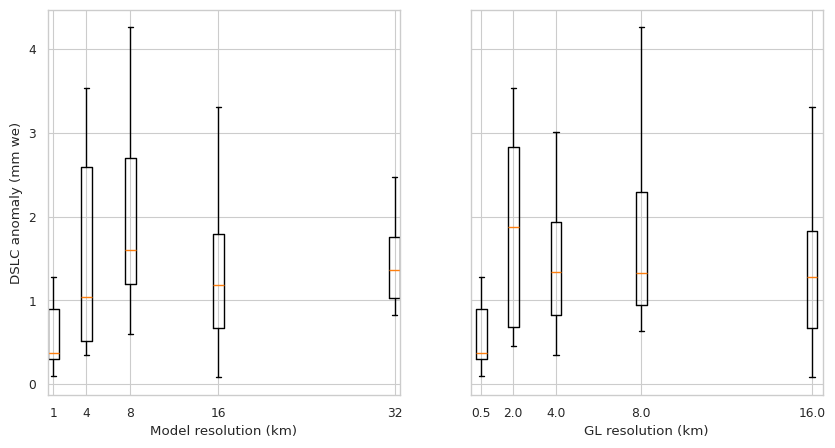

In [43]:
## Make box plots for resolution
f, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)

## Extract data by model resolution
y1 = df.loc[(df['Resolution']==1),'dslc2300']
y2 = df.loc[(df['Resolution']==4),'dslc2300']
y3 = df.loc[(df['Resolution']==8),'dslc2300']
y4 = df.loc[(df['Resolution']==16),'dslc2300']
y5 = df.loc[(df['Resolution']==32),'dslc2300']
stats.kruskal(y1,y2,y3,y4,y5,nan_policy='omit') ## Run statistics

# Make box plot for each model resolution
pos = [1,4,8,16,32]
data = [y1[~np.isnan(y1)],y2[~np.isnan(y2)],y3[~np.isnan(y3)],y4[~np.isnan(y4)],y5[~np.isnan(y5)]]
ax[0].boxplot(data,positions=pos,widths=[1,1,1,1,1]) # Remove nan
ax[0].set_ylabel('DSLC anomaly (mm we)')  
ax[0].set_xlabel('Model resolution (km)') 

## Extract data by GL resolution
y1 = df.loc[(df['Resolution GL']==0.5),'dslc2300']
y2 = df.loc[(df['Resolution GL']==2),'dslc2300']
y3 = df.loc[(df['Resolution GL']==4),'dslc2300']
y4 = df.loc[(df['Resolution GL']==8),'dslc2300']
y5 = df.loc[(df['Resolution GL']==16),'dslc2300']
stats.kruskal(y1,y2,y3,y4,y5,nan_policy='omit') ## Run statistics

pos = [0.5,2,4,8,16]
data = [y1[~np.isnan(y1)],y2[~np.isnan(y2)],y3[~np.isnan(y3)],y4[~np.isnan(y4)],y5[~np.isnan(y5)]]
ax[1].boxplot(data,positions=pos) # Remove nan
ax[1].set_xlabel('GL resolution (km)') 

plt.show()

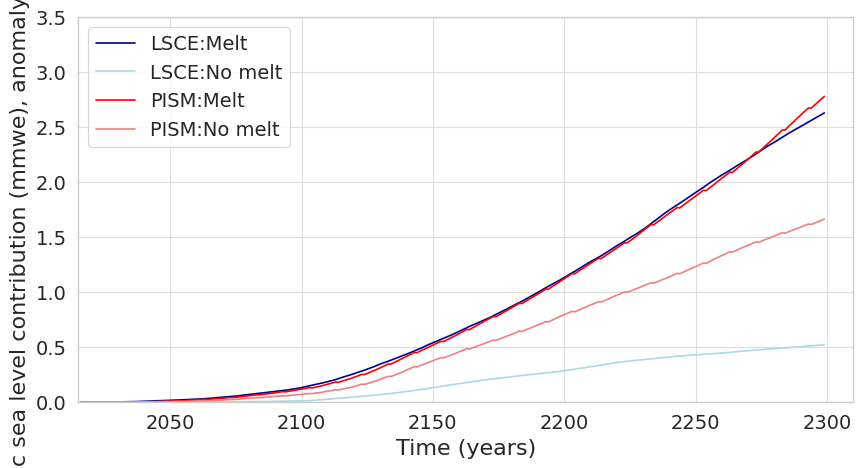

In [65]:
## Look at individual experiments with melt in partially floating cells turned on/off

f,ax = plt.subplots(1,1, figsize = (10,5))

time = dic_dslctime['expAE02']
plt.plot(time['LSCE_GRISLI'],dic_all['LSCE_GRISLI'],c='darkblue',label='LSCE:Melt')
plt.plot(time['LSCE_GRISLI2'],dic_all['LSCE_GRISLI2'],c='lightblue',label='LSCE:No melt')

plt.plot(time['VUW_PISM2'],dic_all['VUW_PISM2'],c='red',label='PISM:Melt')
plt.plot(time['VUW_PISM1'],dic_all['VUW_PISM1'],c='lightcoral',label='PISM:No melt')

ax.set_ylim([0, 3.5])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('DSLC (mmwe), anomaly wrt control', fontsize=16)

ax.legend(loc='upper left', fontsize=14)

ax.set_xlim([2015, 2310])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
#plt.savefig(figures_dir + '/dslc_anom_2300.pdf', format='pdf', bbox_inches='tight')
plt.show()

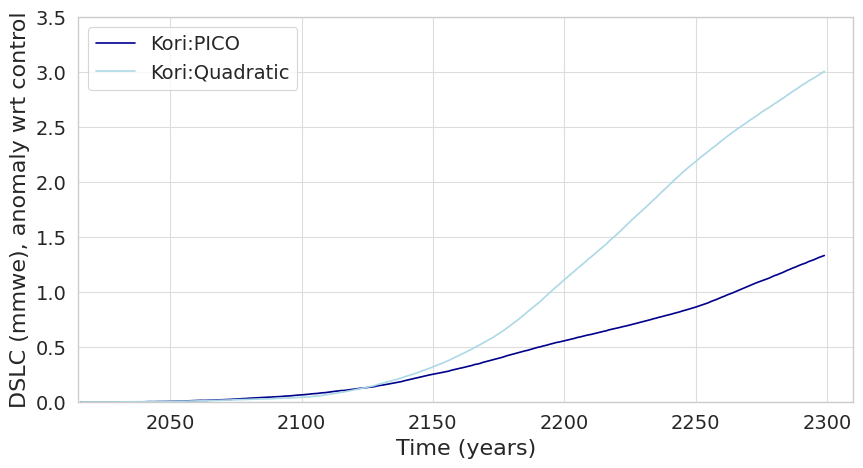

In [67]:
## Look at individual experiments with different melt parameterisations

f,ax = plt.subplots(1,1, figsize = (10,5))

time = dic_dslctime['expAE02']
plt.plot(time['ULB_fETISh-KoriBU1'],dic_all['ULB_fETISh-KoriBU1'],c='darkblue',label='Kori:PICO')
plt.plot(time['ULB_fETISh-KoriBU2'],dic_all['ULB_fETISh-KoriBU2'],c='lightblue',label='Kori:Quadratic')

ax.set_ylim([0, 3.5])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('DSLC (mmwe), anomaly wrt control', fontsize=16)

ax.legend(loc='upper left', fontsize=14)

ax.set_xlim([2015, 2310])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
#plt.savefig(figures_dir + '/dslc_anom_2300.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
## Look at individual experiments with different grid resolutions

f,ax = plt.subplots(1,1, figsize = (10,5))

time = dic_dslctime['expAE02']
plt.plot(time['ULB_fETISh-KoriBU1'],dic_all['ULB_fETISh-KoriBU1'],c='darkblue',label='Kori:PICO')
plt.plot(time['ULB_fETISh-KoriBU2'],dic_all['ULB_fETISh-KoriBU2'],c='lightblue',label='Kori:Quadratic')

ax.set_ylim([0, 3.5])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('DSLC (mmwe), anomaly wrt control', fontsize=16)

ax.legend(loc='upper left', fontsize=14)

ax.set_xlim([2015, 2310])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
#plt.savefig(figures_dir + '/dslc_anom_2300.pdf', format='pdf', bbox_inches='tight')
plt.show()